## 1. Importy i konfiguracja

In [ ]:
# Szymon Drapiński
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})

CLUSTER_COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#f39c12", "#8e44ad"]
NOISE_COLOR = "#bdc3c7"
RANDOM_STATE = 42

## 2. Wczytanie danych z `iris.csv`

Zbiór zawiera 150 próbek, 4 cechy numeryczne i kolumnę `class` (3 gatunki).

In [3]:
df = pd.read_csv("iris.csv")
print(f"Kształt: {df.shape}")
print(f"Klasy: {df['class'].unique()}")
df.head()

Kształt: (150, 5)
Klasy: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.describe()

,sepallength,sepalwidth,petallength,petalwidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
feature_names = ["sepallength", "sepalwidth", "petallength", "petalwidth"]
X = df[feature_names].values

le = LabelEncoder()
y = le.fit_transform(df["class"])
target_names = le.classes_
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Etykiety: {dict(enumerate(target_names))}")

X shape: (150, 4), y shape: (150,)
Etykiety: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}


## 3. Standaryzacja i PCA (do wizualizacji)

**Standaryzacja** jest konieczna dla algorytmów opartych na odległości (K-Means, DBSCAN) – bez niej cechy w większej skali zdominowałyby obliczenia dystansu.

**PCA** redukuje 4 cechy do 2 wymiarów wyłącznie na potrzeby wizualizacji – sama klasteryzacja działa na pełnych standaryzowanych danych.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Wariancja wyjaśniona przez 2 PC: {pca.explained_variance_ratio_.sum():.1%}")

Wariancja wyjaśniona przez 2 PC: 95.8%


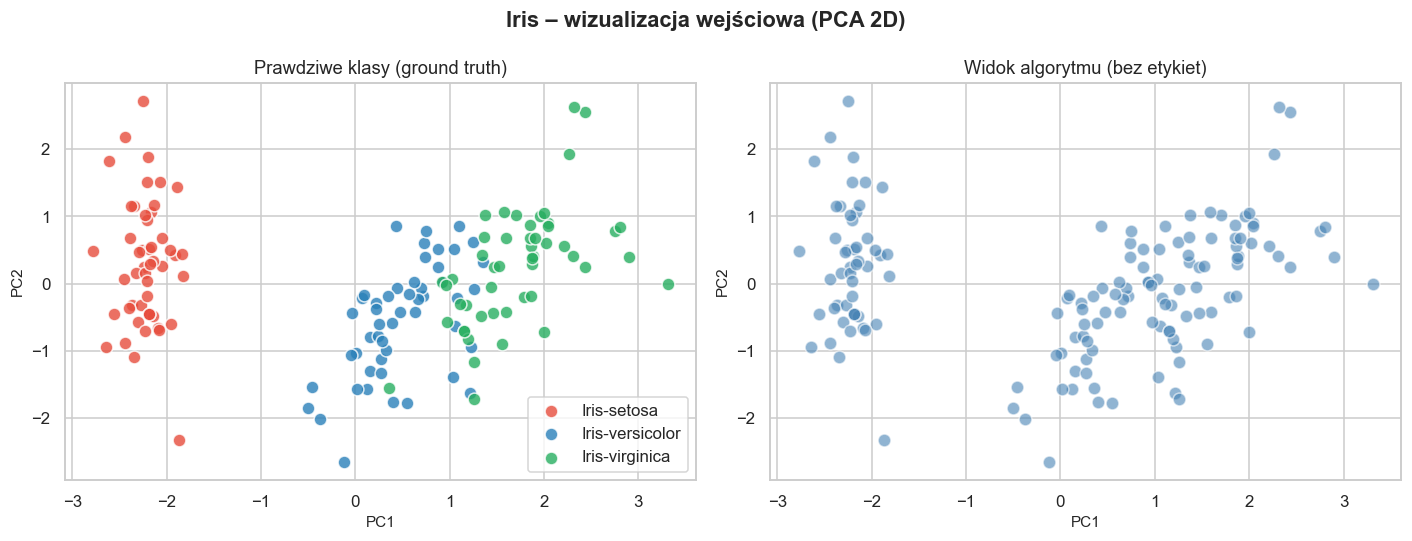

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Iris – wizualizacja wejściowa (PCA 2D)", fontweight="bold")

for i, name in enumerate(target_names):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=CLUSTER_COLORS[i],
                    label=name, alpha=0.8, edgecolors="white", s=70)
axes[0].set_title("Prawdziwe klasy (ground truth)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], color="steelblue", alpha=0.6,
                edgecolors="white", s=70)
axes[1].set_title("Widok algorytmu (bez etykiet)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 4. K-Means

### 4.1 Metoda łokcia (Elbow Method) i Silhouette Score

**Inercja (WCSS)** – suma kwadratów odległości punktów od centroidów. Im mniej, tym zwarciej, ale dla `k=n` spada do 0. Szukamy „łokcia".

**Silhouette Score** ∈ [-1, 1] – mierzy jak dobrze punkty pasują do swojego klastra w porównaniu z sąsiednim. Im wyżej, tym lepiej.

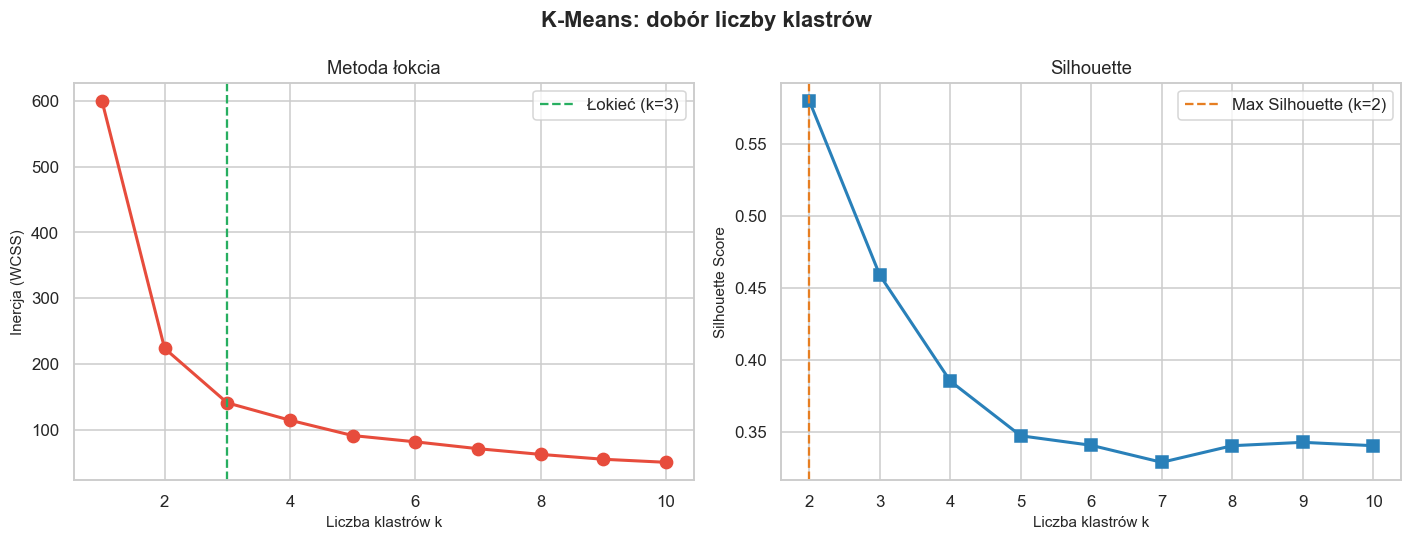

Inercje: [600.0, 223.7, 141.0, 114.6, 91.3, 81.8, 71.3, 62.7, 55.3, 50.6]
Silhouette (k=2..10): [0.58, 0.459, 0.385, 0.347, 0.341, 0.329, 0.34, 0.343, 0.34]


In [8]:
k_range = range(1, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouettes.append(silhouette_score(X_scaled, labels))
    else:
        silhouettes.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("K-Means: dobór liczby klastrów", fontweight="bold")

axes[0].plot(list(k_range), inertias, "o-", color="#e74c3c", linewidth=2, markersize=8)
axes[0].axvline(x=3, color="#27ae60", linestyle="--", label="Łokieć (k=3)")
axes[0].set_xlabel("Liczba klastrów k"); axes[0].set_ylabel("Inercja (WCSS)")
axes[0].set_title("Metoda łokcia"); axes[0].legend()

k_sil = list(k_range)[1:]
best_k = k_sil[int(np.nanargmax(silhouettes[1:]))]
axes[1].plot(k_sil, silhouettes[1:], "s-", color="#2980b9", linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color="#e67e22", linestyle="--",
                label=f"Max Silhouette (k={best_k})")
axes[1].set_xlabel("Liczba klastrów k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Inercje: {[round(v, 1) for v in inertias]}")
print(f"Silhouette (k=2..10): {[round(v, 3) for v in silhouettes[1:]]}")

### 4.2 K-Means – model finalny (k=3)

**Najważniejsze parametry `KMeans`:**
- `n_clusters` – liczba klastrów (musi być znana z góry)
- `init="k-means++"` – inteligentna inicjalizacja centroidów
- `n_init=20` – ile razy uruchomić z różną inicjalizacją (wybierany najlepszy wynik)
- `max_iter=300` – maks. iteracji
- `random_state` – ziarno dla powtarzalności

In [9]:
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=20,
                max_iter=300, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

metrics_km = {
    "Inercja (WCSS)": kmeans.inertia_,
    "Silhouette": silhouette_score(X_scaled, labels_km),
    "Davies-Bouldin": davies_bouldin_score(X_scaled, labels_km),
    "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels_km),
    "Adjusted Rand Index": adjusted_rand_score(y, labels_km),
}
for name, val in metrics_km.items():
    print(f"  {name:<22} {val:.4f}")

  Inercja (WCSS)         140.9658
  Silhouette             0.4590
  Davies-Bouldin         0.8354
  Calinski-Harabasz      239.3418
  Adjusted Rand Index    0.6201


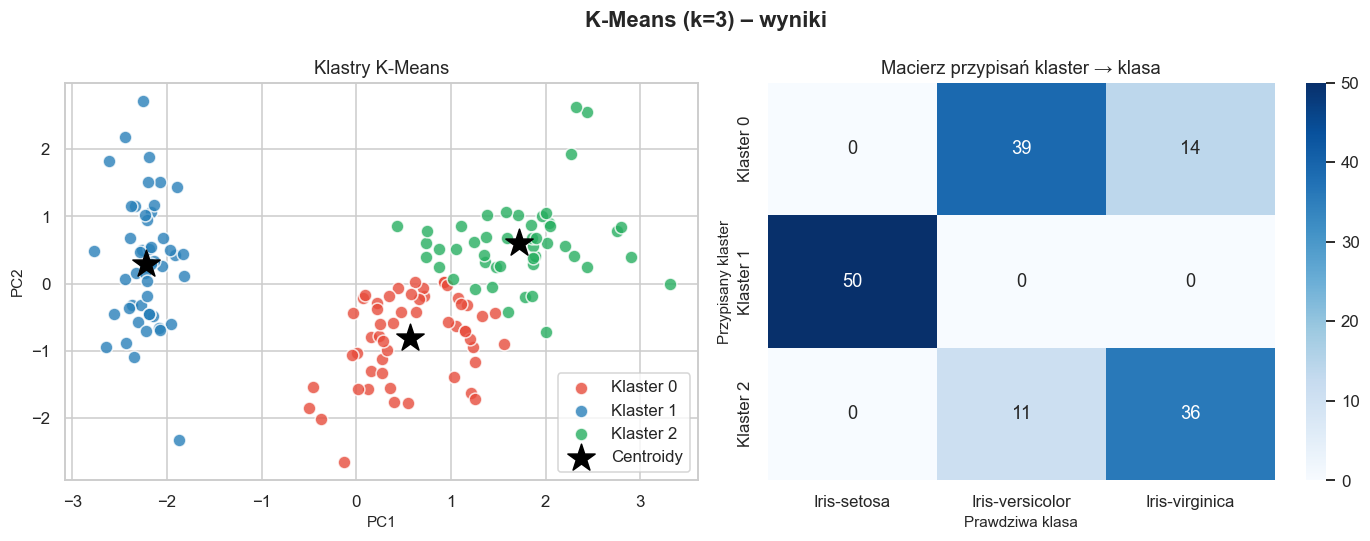

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("K-Means (k=3) – wyniki", fontweight="bold")

for c in range(3):
    mask = labels_km == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=CLUSTER_COLORS[c],
                    label=f"Klaster {c}", alpha=0.8, edgecolors="white", s=70)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="*",
                s=350, color="black", zorder=5, label="Centroidy")
axes[0].set_title("Klastry K-Means"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

conf = np.zeros((3, 3), dtype=int)
for true, pred in zip(y, labels_km):
    conf[pred, true] += 1
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=target_names,
            yticklabels=[f"Klaster {i}" for i in range(3)])
axes[1].set_title("Macierz przypisań klaster → klasa")
axes[1].set_xlabel("Prawdziwa klasa"); axes[1].set_ylabel("Przypisany klaster")
plt.tight_layout(); plt.show()

## 5. DBSCAN

### 5.1 Wykres k-odległości – dobór parametru `eps`

Dla każdego punktu obliczamy odległość do jego *k*-tego najbliższego sąsiada, sortujemy malejąco. „Łokieć" wykresu wskazuje dobrą wartość `eps`.

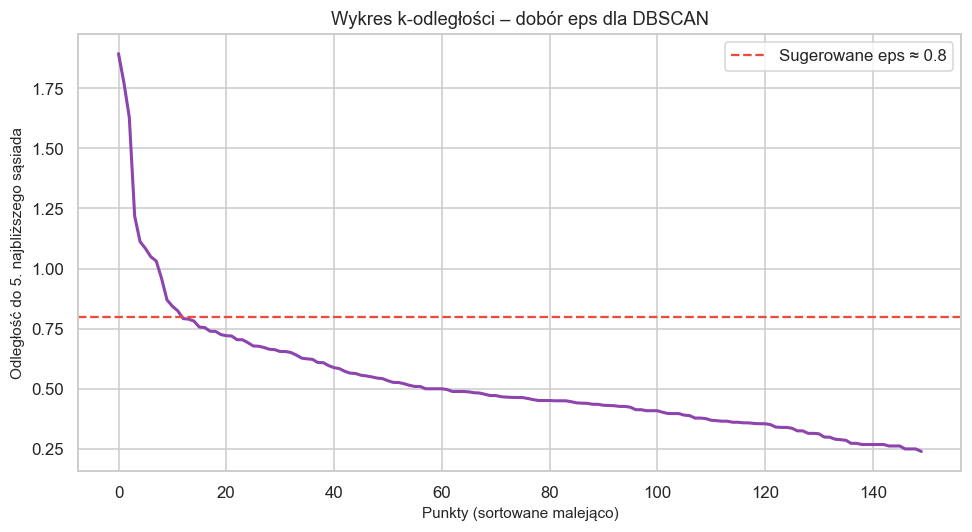

In [11]:
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k - 1])[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_distances, color="#8e44ad", linewidth=2)
ax.axhline(y=0.8, color="#e74c3c", linestyle="--", label="Sugerowane eps ≈ 0.8")
ax.set_xlabel("Punkty (sortowane malejąco)")
ax.set_ylabel(f"Odległość do {k}. najbliższego sąsiada")
ax.set_title("Wykres k-odległości – dobór eps dla DBSCAN")
ax.legend(); plt.tight_layout(); plt.show()

### 5.2 DBSCAN – model finalny

**Najważniejsze parametry `DBSCAN`:**
- `eps` – promień sąsiedztwa (kluczowy hiperparametr)
- `min_samples` – minimalna liczba sąsiadów by punkt był „rdzeniem" klastra (zasada kciuka: ≈ 2 × liczba_cech)
- `metric="euclidean"` – miara odległości

**Typy punktów:** *core* (rdzeń), *border* (brzeg), *noise* (szum, etykieta = -1).

In [12]:
dbscan = DBSCAN(eps=0.8, min_samples=5, metric="euclidean", n_jobs=-1)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int(np.sum(labels_db == -1))

print(f"Liczba klastrów: {n_clusters_db}")
print(f"Punkty szumu:    {n_noise} ({100*n_noise/len(labels_db):.1f}%)")

if n_clusters_db >= 2:
    mask_nn = labels_db != -1
    print(f"Silhouette (bez szumu): {silhouette_score(X_scaled[mask_nn], labels_db[mask_nn]):.4f}")
    print(f"Adjusted Rand Index:    {adjusted_rand_score(y, labels_db):.4f}")

Liczba klastrów: 2
Punkty szumu:    4 (2.7%)
Silhouette (bez szumu): 0.5963
Adjusted Rand Index:    0.5518


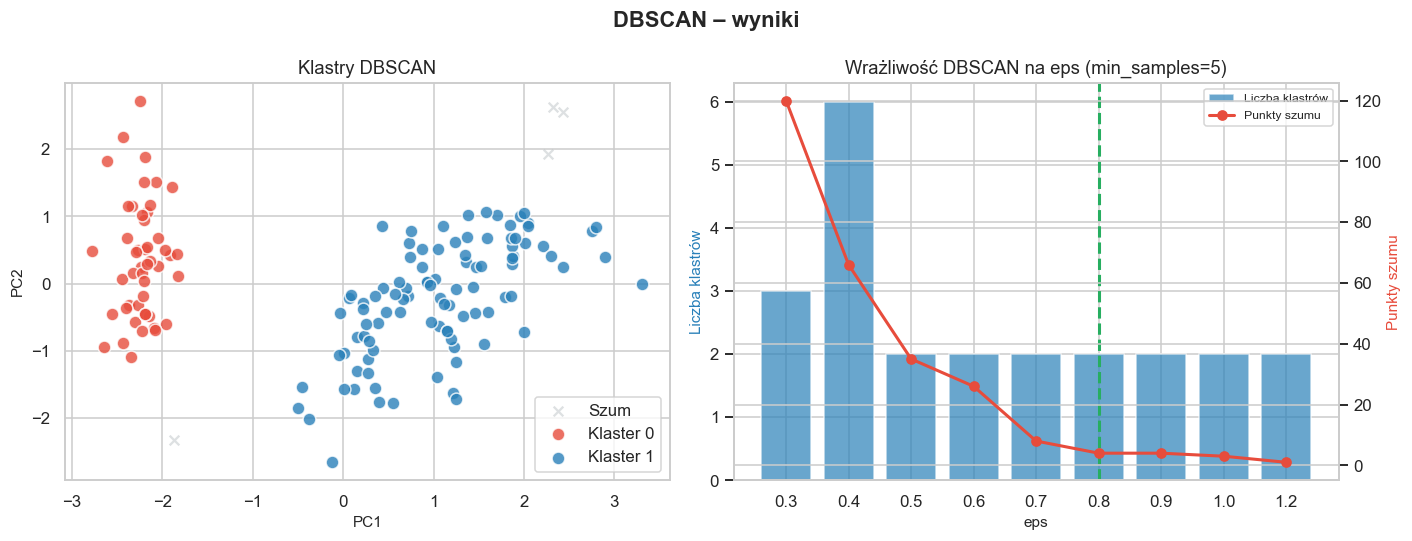

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("DBSCAN – wyniki", fontweight="bold")

unique = sorted(set(labels_db))
ci = 0
for lbl in unique:
    mask = labels_db == lbl
    if lbl == -1:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=NOISE_COLOR,
                        label="Szum", alpha=0.5, marker="x", s=40)
    else:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=CLUSTER_COLORS[ci],
                        label=f"Klaster {lbl}", alpha=0.8, edgecolors="white", s=70)
        ci += 1
axes[0].set_title("Klastry DBSCAN"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]
n_clust_v, n_noise_v = [], []
for e in eps_values:
    lbl = DBSCAN(eps=e, min_samples=5).fit_predict(X_scaled)
    n_clust_v.append(len(set(lbl)) - (1 if -1 in lbl else 0))
    n_noise_v.append(int(np.sum(lbl == -1)))

ax2 = axes[1].twinx()
axes[1].bar([str(e) for e in eps_values], n_clust_v, color="#2980b9",
            alpha=0.7, label="Liczba klastrów")
ax2.plot([str(e) for e in eps_values], n_noise_v, color="#e74c3c",
         marker="o", linewidth=2, label="Punkty szumu")
axes[1].set_xlabel("eps"); axes[1].set_ylabel("Liczba klastrów", color="#2980b9")
ax2.set_ylabel("Punkty szumu", color="#e74c3c")
axes[1].set_title("Wrażliwość DBSCAN na eps (min_samples=5)")
axes[1].axvline(x="0.8", color="#27ae60", linestyle="--", linewidth=2)
lines1, lab1 = axes[1].get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, lab1 + lab2, fontsize=8)
plt.tight_layout(); plt.show()

## 6. Porównanie K-Means vs DBSCAN

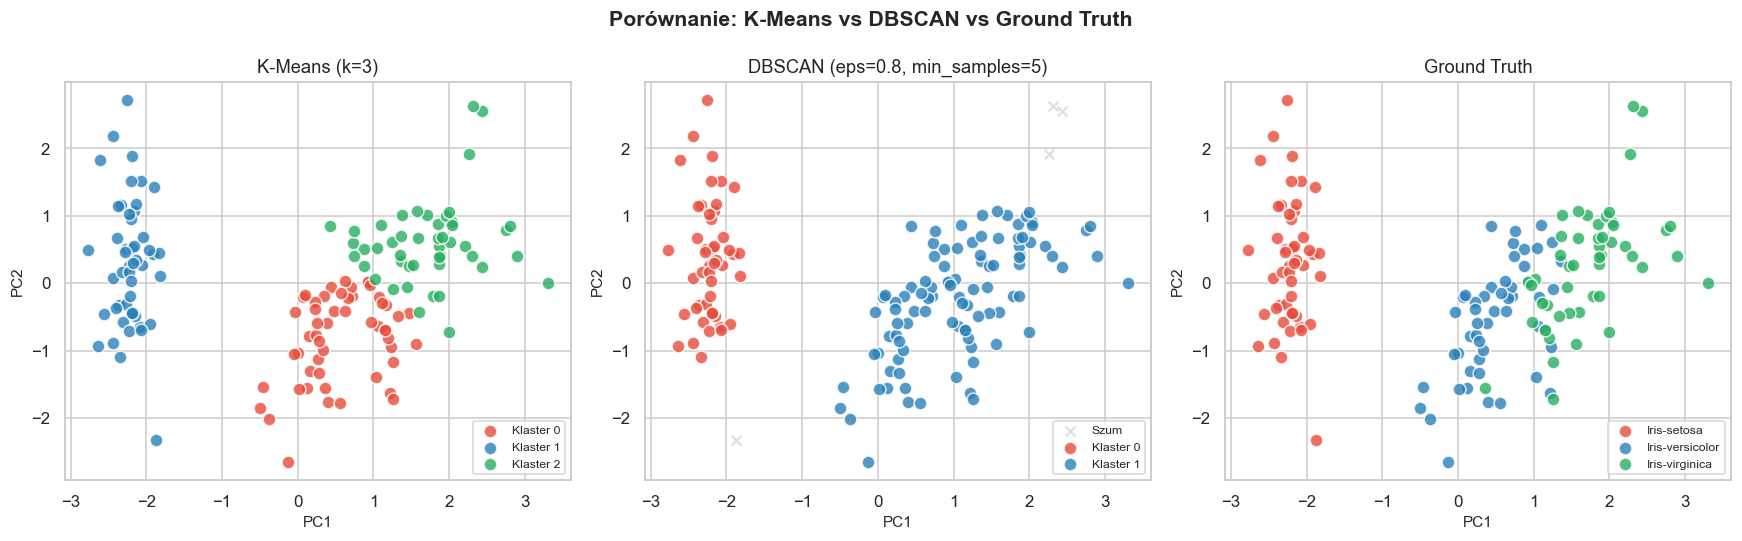

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Porównanie: K-Means vs DBSCAN vs Ground Truth", fontweight="bold", fontsize=14)

datasets = [
    (labels_km, "K-Means (k=3)", axes[0]),
    (labels_db, "DBSCAN (eps=0.8, min_samples=5)", axes[1]),
    (y, "Ground Truth", axes[2]),
]

for labels, title, ax in datasets:
    ci = 0
    for lbl in sorted(set(labels)):
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=NOISE_COLOR,
                       label="Szum", alpha=0.5, marker="x", s=40)
        else:
            name = target_names[lbl] if title == "Ground Truth" else f"Klaster {lbl}"
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=CLUSTER_COLORS[ci],
                       label=name, alpha=0.8, edgecolors="white", s=70)
            ci += 1
    ax.set_title(title); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [15]:
mask_nn = labels_db != -1
summary = pd.DataFrame({
    "K-Means": [
        3,
        0,
        round(silhouette_score(X_scaled, labels_km), 4),
        round(davies_bouldin_score(X_scaled, labels_km), 4),
        round(calinski_harabasz_score(X_scaled, labels_km), 2),
        round(adjusted_rand_score(y, labels_km), 4),
    ],
    "DBSCAN": [
        n_clusters_db,
        n_noise,
        round(silhouette_score(X_scaled[mask_nn], labels_db[mask_nn]), 4) if n_clusters_db >= 2 else np.nan,
        round(davies_bouldin_score(X_scaled[mask_nn], labels_db[mask_nn]), 4) if n_clusters_db >= 2 else np.nan,
        round(calinski_harabasz_score(X_scaled[mask_nn], labels_db[mask_nn]), 2) if n_clusters_db >= 2 else np.nan,
        round(adjusted_rand_score(y, labels_db), 4),
    ],
}, index=[
    "Liczba klastrów",
    "Punkty szumu",
    "Silhouette ↑",
    "Davies-Bouldin ↓",
    "Calinski-Harabasz ↑",
    "Adjusted Rand Index ↑",
])
summary

,K-Means,DBSCAN
Liczba klastrów,3.0000,2.0000
Punkty szumu,0.0000,4.0000
Silhouette ↑,0.4590,0.5963
Davies-Bouldin ↓,0.8354,0.5734
Calinski-Harabasz ↑,239.3400,274.6900
Adjusted Rand Index ↑,0.6201,0.5518


## 7. Wnioski 

### 7.1 Zestawienie metryk

| Metryka | K-Means (k=3) | DBSCAN (eps=0.8, min_samples=5) | Komentarz |
|---|---:|---:|---|
| Liczba klastrów | 3 | **2** | DBSCAN sam zdecydował, że są 2 naturalne skupiska |
| Punkty szumu | 0 | **4** (2.7%) | DBSCAN oznaczył 4 punkty jako odstające |
| Silhouette ↑ | 0.459 | **0.596** | DBSCAN tworzy bardziej zwarte/rozdzielone klastry |
| Davies-Bouldin ↓ | 0.835 | **0.573** | DBSCAN wypada wyraźnie lepiej |
| Calinski-Harabasz ↑ | 239.3 | **274.7** | DBSCAN wypada wyraźnie lepiej|
| Adjusted Rand Index ↑ | **0.620** | 0.552 | K-Means lepiej odtwarza 3 prawdziwe klasy |

### 7.2 Kluczowa obserwacja – sprzeczność metryk wewnętrznych vs ARI

DBSCAN **wygrywa** w metrykach *wewnętrznych* (Silhouette, Davies-Bouldin, Calinski-Harabasz), ale **przegrywa** w *Adjusted Rand Index*. To nie jest sprzeczność – to istota uczenia nienadzorowanego:

- Z perspektywy **geometrii danych** Iris zawiera **2 naturalne skupiska gęstości**: *setosa* (wyraźnie odseparowana) oraz *versicolor + virginica* (jeden ciągły, gęsty obszar). To właśnie znajduje DBSCAN.
- Z perspektywy **etykiet biologicznych** są 3 gatunki – K-Means dostaje narzucone `k=3` i sztucznie tnie obszar *versicolor/virginica* na dwie części, dlatego ma lepsze ARI.
- Potwierdza to **Silhouette dla K-Means** w funkcji `k`: maksimum wypada przy **k=2 (0.580)**, a nie przy k=3 (0.459). Sam algorytm pokazuje że naturalna struktura ma 2 klastry – zgodnie z DBSCAN.

### 7.3 Macierze przypisań 

**K-Means (k=3):** *setosa* perfekcyjnie (50/50), ale *versicolor* i *virginica* mocno pomieszane:
- Klaster 0: 39 versicolor + 14 virginica
- Klaster 1: 50 setosa
- Klaster 2: 11 versicolor + 36 virginica
- → łącznie **25/100 błędnych przypisań** w obszarze versicolor/virginica.

**DBSCAN (eps=0.8):**
- Klaster 0 = *setosa* (49 z 50, jeden punkt jako szum)
- Klaster 1 = *versicolor* (50) + *virginica* (47) razem
- Szum: 1 setosa + 3 virginica – realne punkty na obrzeżach skupisk.

### 7.4 Metoda łokcia 

Spadki inercji: 600 → 224 → **141** → 115 → 91 → 82 → 71 → 63 → 55 → 51

- Największy spadek między k=1 a k=2 (~376), spory między k=2 a k=3 (~83), potem już znacznie mniejsze (~25 i mniej). „Łokieć" jest między k=2 i k=3 – obie wartości można uzasadnić, ale **Silhouette wskazuje k=2 jako najlepsze**.

### 7.5 Wniosek końcowy

Dla zbioru Iris **żaden algorytm nie jest bezwzględnie lepszy** – wybór zależy od pytania badawczego:

- Jeśli zależy nam na odtworzeniu *gatunków* (mając wiedzę domenową, że są 3) → **K-Means z k=3** (ARI = 0.620).
- Jeśli pytamy „ile naturalnych skupisk widać w danych?" → uczciwą odpowiedzią DBSCAN jest **2 klastry + kilka punktów odstających** (Silhouette = 0.596).

w zastosowaniach uczenia nienadzorowanego znamy tylko metryki wewnętrzne. Te wskazałyby DBSCAN jako lepszy wybór, mimo że biologicznie „prawda" to 3 klasy. Pokazuje to, że klasteryzacja **odkrywa strukturę danych**, a niekoniecznie zaplanowane przez nas etykiety.